# Compare the Perovskite with and without prewetting:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from plot_module.solsim_analyzer import solarSimulator

sns.set(style='whitegrid', context='talk')

### Load the folders:

In [2]:
folderPath_With = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/With_Without_Prewetting/Data_Used/With_Prewetting'
folderPath_Without = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/With_Without_Prewetting/Data_Used/Without_Prewetting'

### Helper to load metrics from folders

In [3]:
def load_metrics(folder: str):
    """Return dict of lists for Isc, Voc, FF, PCE from a folder."""
    analyzer = solarSimulator(folderPath=folder)
    analyzer.loadFolderData()
    return {
        'Isc': list(analyzer.Isc),
        'Voc': list(analyzer.Voc),
        'FF':  list(analyzer.FF),
        'PCE': list(analyzer.PCE),
    }


### Define groups (with vs without prewetting)

In [4]:
GROUPS = {
    'With prewetting': folderPath_With,
    'Without prewetting': folderPath_Without,
}

# Optional: sanity-check paths are filled
missing = [k for k,v in GROUPS.items() if not v]
if missing:
    print('Please set folder paths for:', ', '.join(missing))


### Box plot: PCE distribution by prewetting

[-0.57564475 -1.92825799 -2.96669511 -3.74899703 -4.33158237 -4.76164962
 -5.07423039 -5.28578589 -5.4432588  -5.5448656  -5.61370276 -5.66440133
 -5.6886327  -5.69679822 -5.68625176 -5.67029841 -5.64673809 -5.60909616
 -5.57033698 -5.51836609 -5.46383872 -5.40588204 -5.34415874 -5.27771927
 -5.20892789 -5.13623252 -5.05845156 -4.98089453 -4.90175348 -4.82033345
 -4.73562623 -4.65112658 -4.56490401 -4.47644371 -4.38711174 -4.29574709
 -4.20457116 -4.11092131 -4.01714309 -3.92002808 -3.82414203 -3.72511283
 -3.62723194 -3.52767049 -3.42667225 -3.32585458 -3.22267962 -3.11938688
 -3.01477868 -2.91037246 -2.80486946 -2.69853752 -2.59205719 -2.48507331
 -2.37820903 -2.26961725 -2.16043337 -2.0513724  -1.94250907 -1.83274467
 -1.7222426  -1.61121973 -1.50086013 -1.38967404 -1.27845773 -1.16628355
 -1.05384826 -0.94121532 -0.8286379  -0.715685   -0.6023663  -0.48885058
 -0.37516651 -0.26123495 -0.14704038 -0.03270641]
3o_1_px2_Light_forward_0
[ -1.32049403  -4.29534507  -6.58388795  -8.29208

/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_34998/3310930957.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Group', y='Value', order=order, palette=palette)


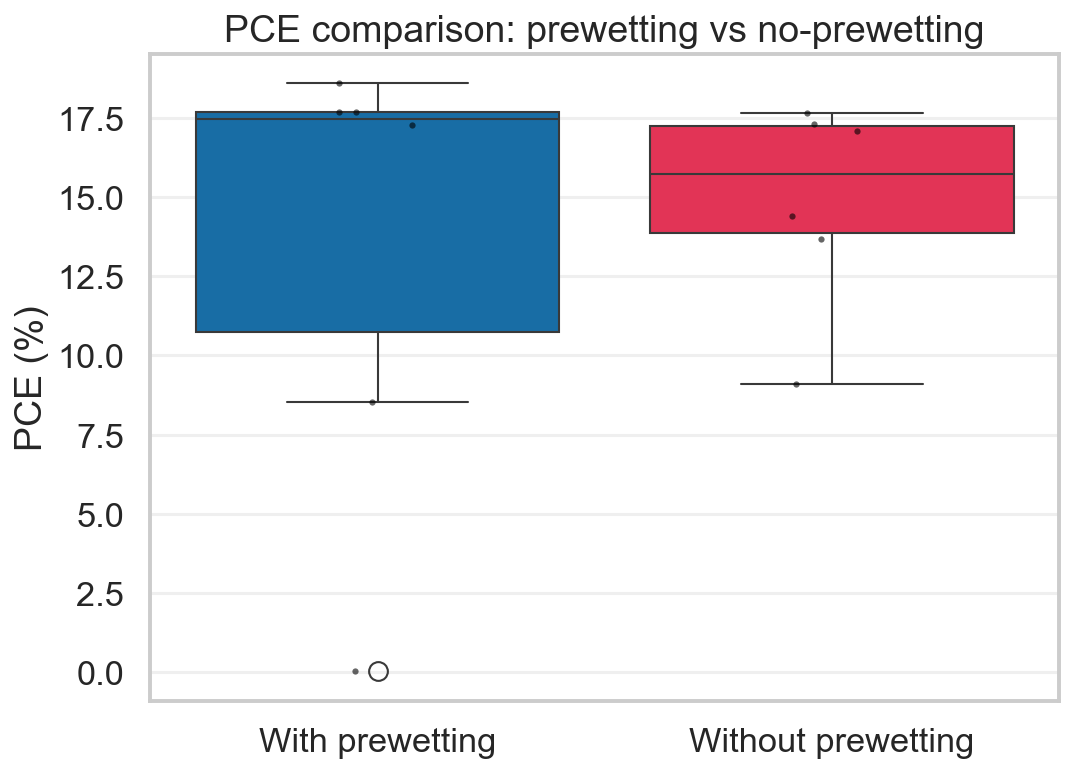

In [5]:
# Load groups
records = []
for group, folder in GROUPS.items():
    if not folder:
        continue
    try:
        m = load_metrics(folder)
        for p in m['PCE']:
            records.append({'Group': group, 'Metric': 'PCE', 'Value': p})
    except Exception as e:
        print(f'Skipping {group}:', e)

df = pd.DataFrame(records)

# Group means for quick comparison
if not df.empty:
    means = df.groupby('Group')['Value'].mean().round(3)
    print('Group means (PCE %):')
    print(means.to_string())

# Plot
plt.figure(figsize=(7.5, 5.5), dpi=150)
order = list(GROUPS.keys())
palette = ['#0072BD', '#FF1744']
sns.boxplot(data=df, x='Group', y='Value', order=order, palette=palette)
sns.stripplot(data=df, x='Group', y='Value', order=order, color='black', size=3, jitter=True, alpha=0.6)
plt.ylabel('PCE (%)')
plt.xlabel('')
plt.title('PCE comparison: prewetting vs no-prewetting')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Box plots: Voc, Isc, FF

/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_34998/149494327.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Group', y='Value', order=order, palette=palette)


[-0.57564475 -1.92825799 -2.96669511 -3.74899703 -4.33158237 -4.76164962
 -5.07423039 -5.28578589 -5.4432588  -5.5448656  -5.61370276 -5.66440133
 -5.6886327  -5.69679822 -5.68625176 -5.67029841 -5.64673809 -5.60909616
 -5.57033698 -5.51836609 -5.46383872 -5.40588204 -5.34415874 -5.27771927
 -5.20892789 -5.13623252 -5.05845156 -4.98089453 -4.90175348 -4.82033345
 -4.73562623 -4.65112658 -4.56490401 -4.47644371 -4.38711174 -4.29574709
 -4.20457116 -4.11092131 -4.01714309 -3.92002808 -3.82414203 -3.72511283
 -3.62723194 -3.52767049 -3.42667225 -3.32585458 -3.22267962 -3.11938688
 -3.01477868 -2.91037246 -2.80486946 -2.69853752 -2.59205719 -2.48507331
 -2.37820903 -2.26961725 -2.16043337 -2.0513724  -1.94250907 -1.83274467
 -1.7222426  -1.61121973 -1.50086013 -1.38967404 -1.27845773 -1.16628355
 -1.05384826 -0.94121532 -0.8286379  -0.715685   -0.6023663  -0.48885058
 -0.37516651 -0.26123495 -0.14704038 -0.03270641]
3o_1_px2_Light_forward_0
[ -1.32049403  -4.29534507  -6.58388795  -8.29208

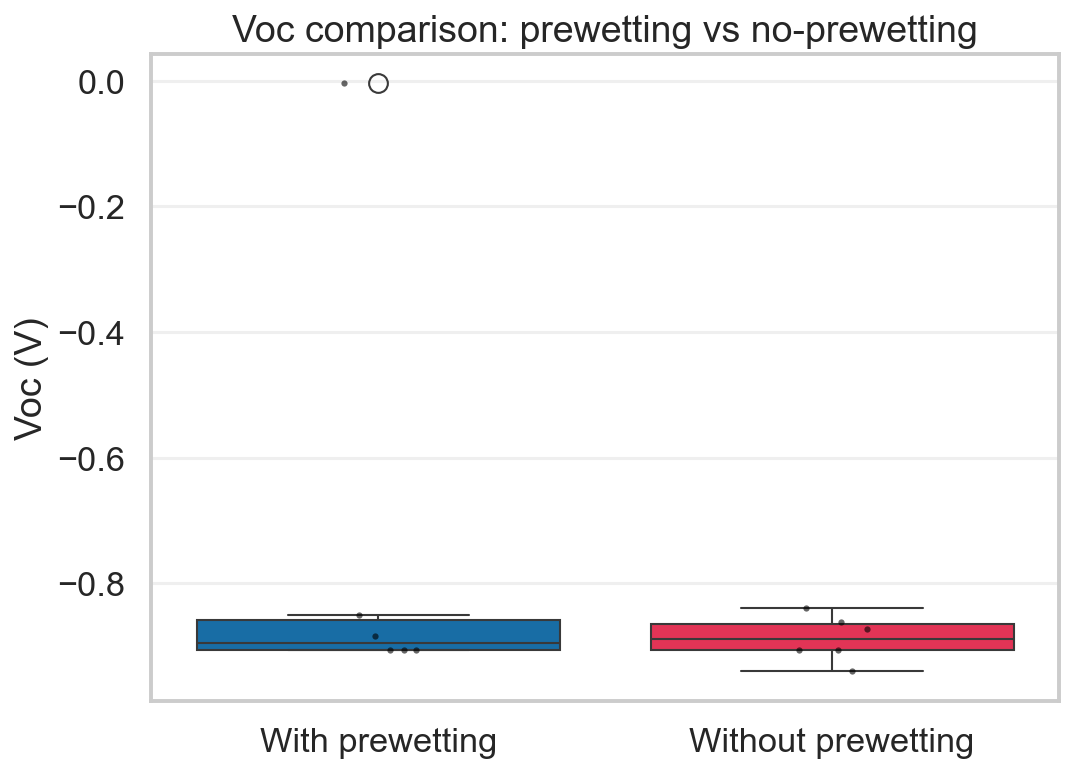

Group means (Isc):
Group
With prewetting       11.681
Without prewetting    12.971


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_34998/149494327.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Group', y='Value', order=order, palette=palette)


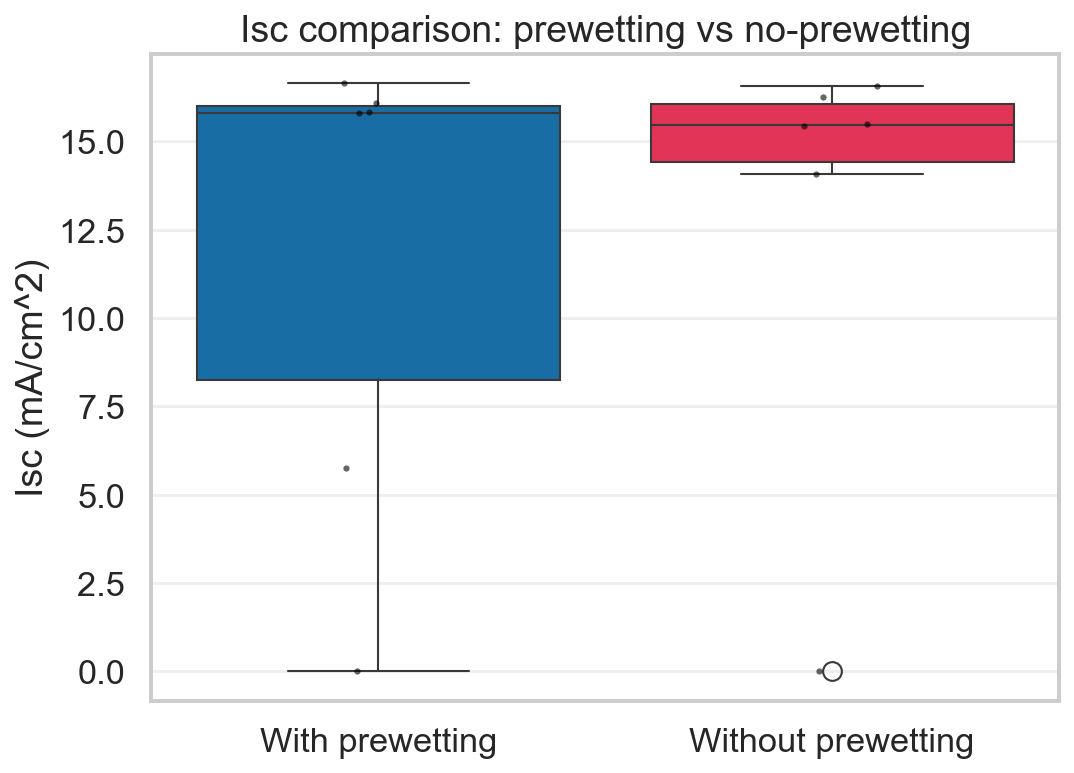

Group means (FF):
Group
With prewetting       0.823
Without prewetting    0.703


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_34998/149494327.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='Group', y='Value', order=order, palette=palette)


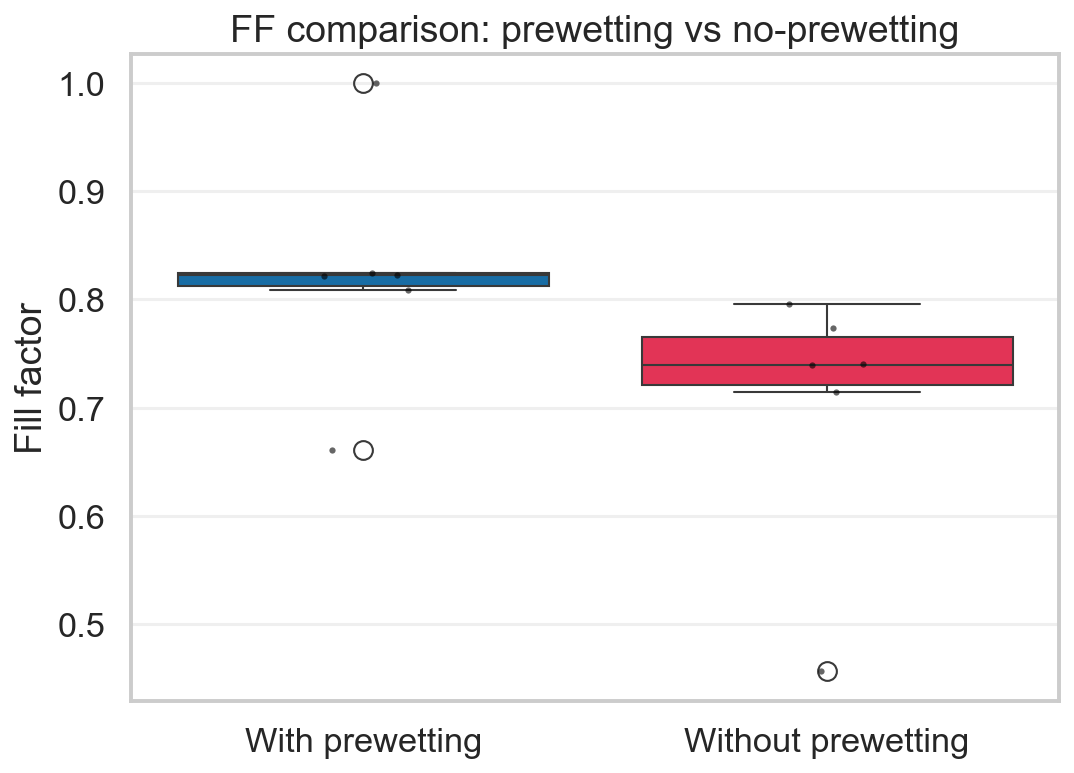

In [6]:
# Build records for non-PCE metrics
records = []
for group, folder in GROUPS.items():
    if not folder:
        continue
    try:
        m = load_metrics(folder)
        for metric in ['Voc', 'Isc', 'FF']:
            for val in m.get(metric, []):
                records.append({'Group': group, 'Metric': metric, 'Value': val})
    except Exception as e:
        print(f'Skipping {group}:', e)

dfm = pd.DataFrame(records)

if dfm.empty:
    print('No data available for Voc/Isc/FF.')
else:
    order = list(GROUPS.keys())
    palette = ['#0072BD', '#FF1744']
    for metric, ylabel, title in [
        ('Voc', 'Voc (V)', 'Voc comparison: prewetting vs no-prewetting'),
        ('Isc', 'Isc (mA/cm^2)', 'Isc comparison: prewetting vs no-prewetting'),
        ('FF', 'Fill factor', 'FF comparison: prewetting vs no-prewetting'),
    ]:
        d = dfm[dfm['Metric'] == metric]
        if d.empty:
            print(f'No data for {metric}.')
            continue
        means = d.groupby('Group')['Value'].mean().round(3)
        print(f'Group means ({metric}):')
        print(means.to_string())
        plt.figure(figsize=(7.5, 5.5), dpi=150)
        sns.boxplot(data=d, x='Group', y='Value', order=order, palette=palette)
        sns.stripplot(data=d, x='Group', y='Value', order=order, color='black', size=3, jitter=True, alpha=0.6)
        plt.ylabel(ylabel)
        plt.xlabel('')
        plt.title(title)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


### IV curves: best PCE in each group

[-0.57564475 -1.92825799 -2.96669511 -3.74899703 -4.33158237 -4.76164962
 -5.07423039 -5.28578589 -5.4432588  -5.5448656  -5.61370276 -5.66440133
 -5.6886327  -5.69679822 -5.68625176 -5.67029841 -5.64673809 -5.60909616
 -5.57033698 -5.51836609 -5.46383872 -5.40588204 -5.34415874 -5.27771927
 -5.20892789 -5.13623252 -5.05845156 -4.98089453 -4.90175348 -4.82033345
 -4.73562623 -4.65112658 -4.56490401 -4.47644371 -4.38711174 -4.29574709
 -4.20457116 -4.11092131 -4.01714309 -3.92002808 -3.82414203 -3.72511283
 -3.62723194 -3.52767049 -3.42667225 -3.32585458 -3.22267962 -3.11938688
 -3.01477868 -2.91037246 -2.80486946 -2.69853752 -2.59205719 -2.48507331
 -2.37820903 -2.26961725 -2.16043337 -2.0513724  -1.94250907 -1.83274467
 -1.7222426  -1.61121973 -1.50086013 -1.38967404 -1.27845773 -1.16628355
 -1.05384826 -0.94121532 -0.8286379  -0.715685   -0.6023663  -0.48885058
 -0.37516651 -0.26123495 -0.14704038 -0.03270641]
3o_1_px2_Light_forward_0
[ -1.32049403  -4.29534507  -6.58388795  -8.29208

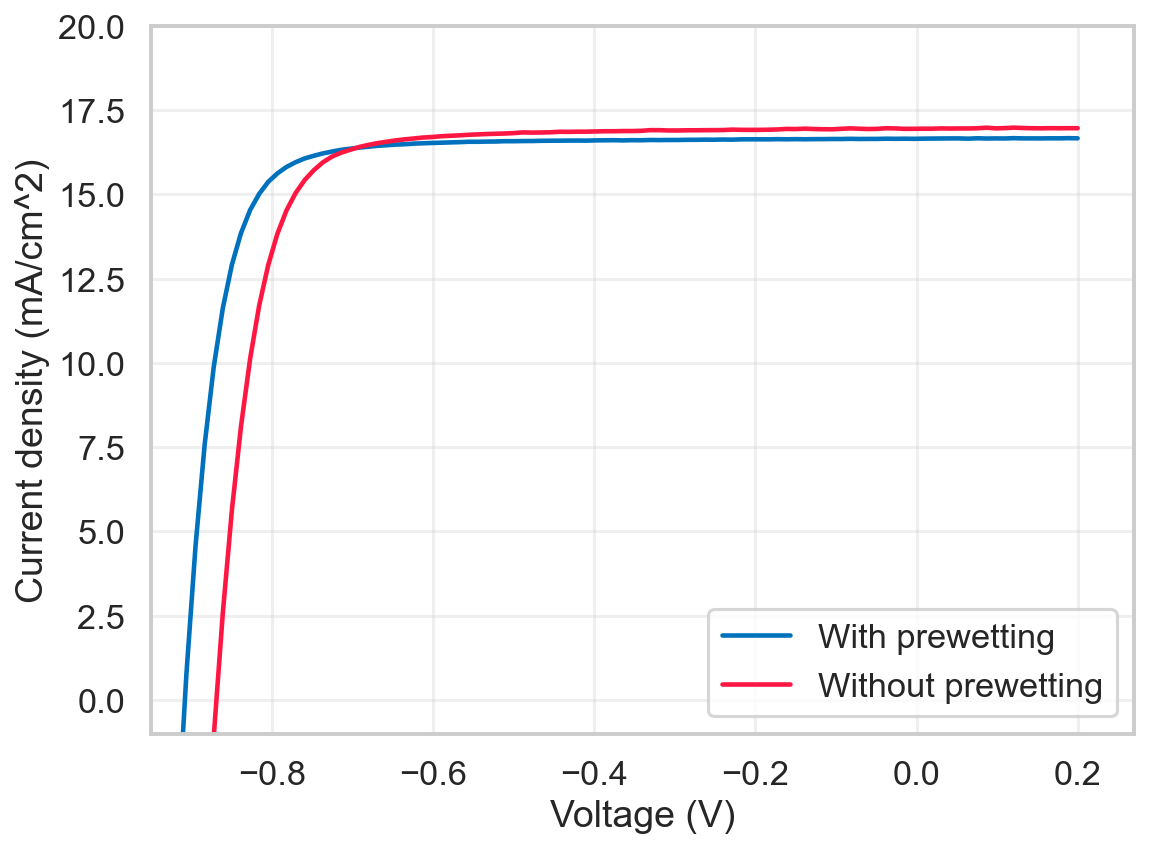

In [7]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
group_palette = {
    'With prewetting': '#0072BD',
    'Without prewetting': '#FF1744',
}
for group, folder in GROUPS.items():
    if not folder:
        continue
    try:
        analyzer = solarSimulator(folderPath=folder)
        analyzer.loadFolderData()
        if not analyzer.PCE:
            continue
        # Index of best PCE in this group
        best_idx = max(range(len(analyzer.PCE)), key=lambda i: analyzer.PCE[i])
        v = analyzer.voltages[best_idx]
        j = analyzer.currents[best_idx]
        label = f'{group}'
        ax.plot(v, j, label=label, color=group_palette.get(group, None), linewidth=2.2)
    except Exception as e:
        print(f'Skipping IV for {group}:', e)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Current density (mA/cm^2)')
ax.set_ylim(-1, 20)
ax.set_xlim(-0.95, )
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
